In [1]:
from selenium import webdriver
from tqdm import tqdm

In [2]:
from selenium.webdriver.common.by import By

In [3]:
options = webdriver.EdgeOptions()

In [4]:
options.add_argument('--no-sandbox')
options.add_experimental_option('excludeSwitches', ['enable-automation'])
options.add_experimental_option('useAutomationExtension', False)

In [5]:
driver = webdriver.Edge(options=options)

In [6]:
driver.maximize_window()
driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
    "source": """
    Object.defineProperty(navigator, 'webdriver', {
        get: () => undefined
    })
    """
})

{'identifier': '2'}

In [7]:
driver.get('https://cvpr.thecvf.com/Conferences/2024/AcceptedPapers')

In [10]:
btn = driver.find_element(By.XPATH,"/html/body/main/div[2]/div/div/div/div/table/tbody/tr[3]/td[1]/strong")

In [11]:
btn.text

'Unsupervised Template-assisted Point Cloud Shape Correspondence Network'

In [12]:
title_list = []
withcode = 0
xpath_tmp = "/html/body/main/div[2]/div/div/div/div/table/tbody/tr[{}]/td[1]/"
for i in tqdm(range(3,2718)):
    xpath_id = xpath_tmp.format(i)
    try:
        btn = driver.find_element(By.XPATH,xpath_id+"a")
        withcode += 1
    except:
        btn = driver.find_element(By.XPATH,xpath_id+"strong")
    finally:
        title_list.append(btn.text)

100%|██████████████████████████████████████████████████████████████████████████████| 2715/2715 [01:36<00:00, 28.13it/s]


In [13]:
withcode/len(title_list)* 100 

37.42173112338858

In [14]:
title_list

['Unsupervised Template-assisted Point Cloud Shape Correspondence Network',
 'X-3D: Explicit 3D Structure Modeling for Point Cloud Recognition',
 'Spectral and Polarization Vision: Spectro-polarimetric Real-world Dataset',
 'Efficient Model Stealing Defense with Noise Transition Matrix',
 'HOIAnimator: Generating Text-prompt Human-object Animations using Novel Perceptive Diffusion Models',
 'InstructVideo: Instructing Video Diffusion Models with Human Feedback',
 'HDQMF: Holographic Feature Decomposition Using Quantum Algorithms',
 'VideoCon: Robust Video-Language Alignment via Contrast Captions',
 'Going Beyond Multi-Task Dense Prediction with Synergy Embedding Models',
 'BiPer: Binary Neural Networks using a Periodic Function',
 'ToonerGAN: Reinforcing GANs for Obfuscating Automated Facial Indexing',
 'UniBind: LLM-Augmented Unified and Balanced Representation Space to Bind Them All',
 'Robust Synthetic-to-Real Transfer for Stereo Matching',
 'Learning Intra-view and Cross-view Geome

In [15]:
driver.close()

In [16]:
import json

In [17]:
with open("cvpr_2024_title.json", 'w') as  f:
    json.dump(title_list, f)

In [18]:
from wordcloud import (WordCloud, get_single_color_func, STOPWORDS, ImageColorGenerator)
import matplotlib.pyplot as plt

In [19]:
txt_stop = """a an . , : ? the is in to of via be from by with and or for - on"""

In [20]:
text_all = " ".join(title_list)

In [21]:
stop_words_list = txt_stop.split(" ")
stopwords = set(STOPWORDS)
for w in stop_words_list:
    stopwords.add(w)

In [22]:
wordcloud = WordCloud(
    background_color="white",
    width=1000, 
    height=860, 
    margin=2,
    max_font_size=196,
    max_words=256,
    random_state=96,
    stopwords=stopwords,
).generate(text_all.lower())

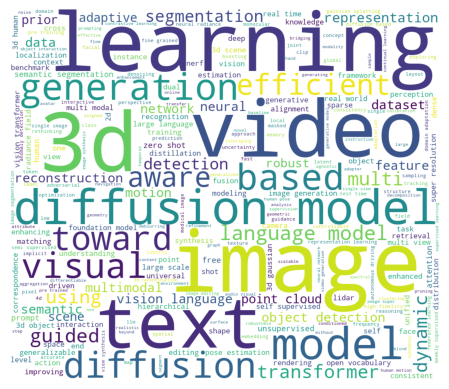

In [23]:
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [24]:
wordcloud.to_file('wordcloud_cvpr2024_title.pdf')

In [25]:
from collections import Counter

In [26]:
wordcount = Counter([i.lower() for i in text_all.split(" ") if i.lower() not in stop_words_list])

In [27]:
wordcount

Counter({'learning': 358,
         '3d': 348,
         'models': 286,
         'diffusion': 284,
         'image': 283,
         'generation': 194,
         'video': 190,
         'segmentation': 168,
         'detection': 162,
         'model': 158,
         'neural': 148,
         'object': 142,
         'visual': 126,
         'human': 121,
         'towards': 107,
         'semantic': 105,
         'reconstruction': 101,
         'efficient': 94,
         'scene': 92,
         'estimation': 90,
         'language': 83,
         'using': 82,
         'representation': 82,
         'motion': 79,
         'vision': 77,
         'point': 76,
         'synthesis': 72,
         'large': 72,
         'multimodal': 72,
         'pose': 69,
         'dynamic': 67,
         'transformer': 66,
         'vision-language': 62,
         'understanding': 62,
         'dataset': 60,
         'text-to-image': 60,
         'adaptation': 59,
         'generative': 59,
         'unsupervised': 57,
   